In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import gc

In [ ]:
# Connect my drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# load my data file located at my drive/M2 Intership/pi0 calibration
%cd /content/drive/MyDrive/M2 Internship/pi0 calibration

/content/drive/MyDrive/M2 Internship/pi0 calibration


In [ ]:
def minimize_eps(m2: np.ndarray, m0_sq: float, E: np.ndarray,
                 *, rcond: float = 1e-12):
    """
    Solve ε = C⁻¹ (D – λ L) with C, D, L, λ defined in the paper.

    Parameters
    ----------
    m2      : shape (N,)   – event–by–event squared masses  m_i²
    m0_sq   : float        – nominal squared mass           m₀²
    E       : shape (N,K)  – per–event, per-bin weights     E_{ji}^{(k)}
    rcond   : float        – cut-off for pseudo-inverse if C is ill-conditioned

    Returns
    -------
    eps     : shape (K,)   – the ε_k that minimise the constrained χ²
    lam     : float        – the Lagrange multiplier λ
    """

    # ---- Eq. (3.21): ∂m_i²/∂ε_k  -------------------------------------------
    denom   = E.sum(axis=1, keepdims=True)            # Σ_k′ E_{ji}^{(k′)}
    grad    = m2[:, None] * E / denom                 # shape (N,K)

    # ---- Eqs. (3.25)–(3.27): C, D, L  -------------------------------------
    C   = grad.T @ grad                               # (K,K)
    D   = -( (m2 - m0_sq)[:, None] * grad ).sum(0)    # (K,)
    L   = grad.sum(0)                                 # (K,)

    # ---- optional: stabilise C if it is nearly singular --------------------
    Cinv = np.linalg.pinv(C, rcond=rcond)

    # ---- Eq. (3.29): B -----------------------------------------------------
    B   = (m2 - m0_sq).sum()

    # ---- Eq. (3.28): λ -----------------------------------------------------
    lam = (B + L @ Cinv @ D) / (L @ Cinv @ L)

    # ---- Eq. (3.24): ε_k ---------------------------------------------------
    eps = Cinv @ (D - lam * L)
    return eps, lam

ε stats: min=7.054e-02, max=1.869e-01, mean=9.712e-02
Iter 01:  Δε = 5.141e+00   F = 2.893797
ε stats: min=-1.171e-02, max=3.303e-03, mean=-5.384e-03
Iter 02:  Δε = 5.412e+00   F = 1.278293
ε stats: min=-5.893e-02, max=-2.243e-02, mean=-3.048e-02
Iter 03:  Δε = 1.345e+00   F = 1.097820
ε stats: min=-7.433e-03, max=3.632e-03, mean=1.033e-04
Iter 04:  Δε = 1.610e+00   F = 0.852123
ε stats: min=8.145e-03, max=2.062e-02, mean=1.070e-02
Iter 05:  Δε = 5.689e-01   F = 0.846677
ε stats: min=4.228e-05, max=6.346e-03, mean=1.882e-03
Iter 06:  Δε = 4.631e-01   F = 0.809629
ε stats: min=-6.955e-03, max=-3.056e-03, mean=-3.701e-03
Iter 07:  Δε = 2.964e-01   F = 0.816316
ε stats: min=-4.035e-03, max=-1.116e-03, mean=-1.907e-03
Iter 08:  Δε = 9.572e-02   F = 0.807141
ε stats: min=-7.491e-05, max=1.984e-03, mean=8.968e-04
Iter 09:  Δε = 1.477e-01   F = 0.808570
ε stats: min=9.372e-04, max=2.475e-03, mean=1.238e-03
Iter 10:  Δε = 2.145e-02   F = 0.807123
ε stats: min=-8.608e-05, max=8.625e-04, mean=1.

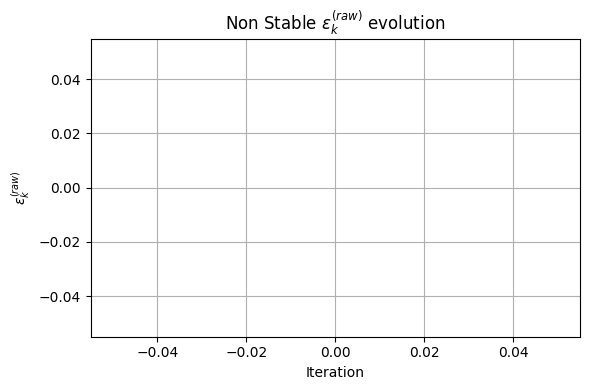

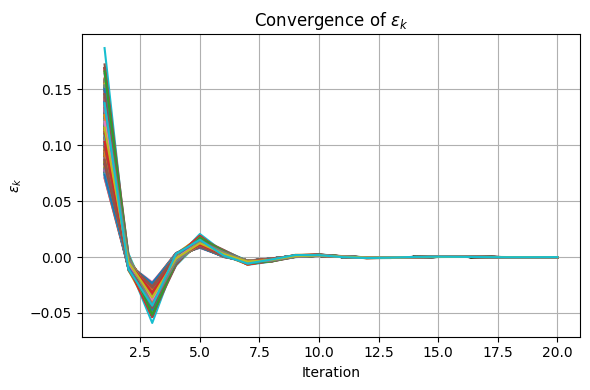

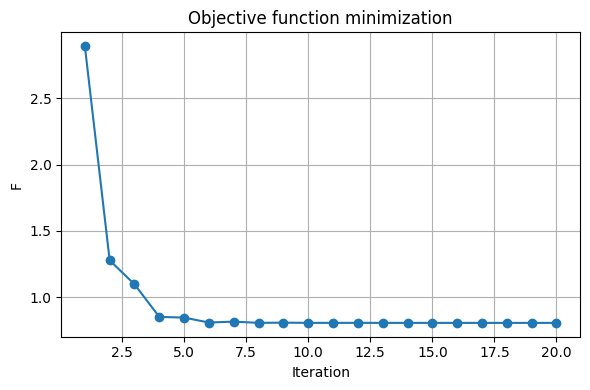

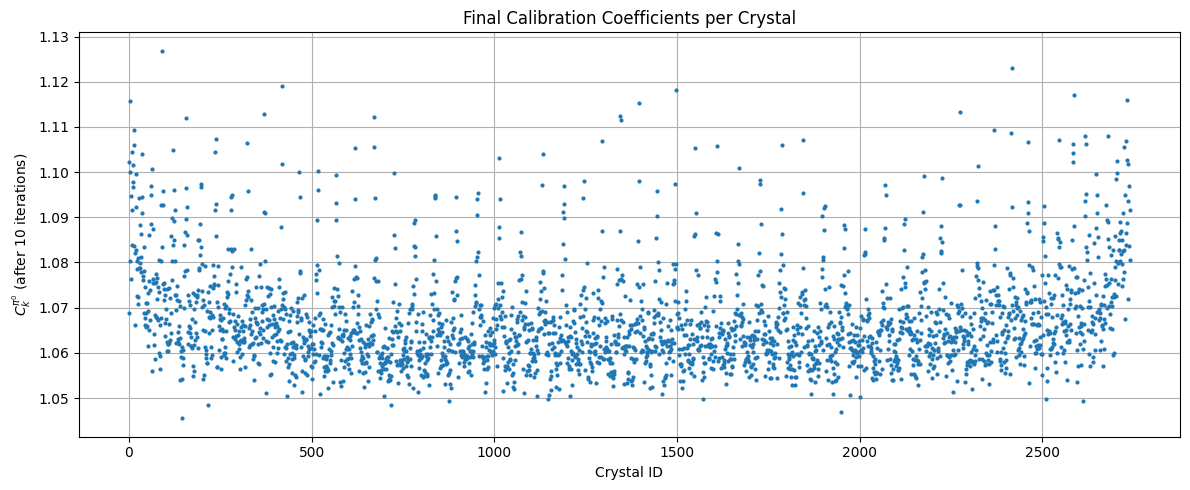

In [ ]:
df = pd.read_csv("photon_output_5x41_TwoSigma_25.03.01_run1to50_mod_ok (2).csv")
df["crystal_id"] = df["crystal_id"].astype(int)

# geometry: constant crystal-centre z (mm)
z = -1850.130
df["r3"] = np.sqrt(df["x"]**2 + df["y"]**2 + z**2)
df["ux"] = df["x"] / df["r3"]
df["uy"] = df["y"] / df["r3"]
df["uz"] = z       / df["r3"]

# ---------- 2.  prepare wide matrix of per-event, per-crystal energies  ----
# per-event, per-crystal energy matrix  (sparse -> dense)
wide_raw = df.pivot(index="event", columns="photon")          # one row = one π0 event

E_df = (
    df.groupby(["event", "crystal_id"])["photon_energy"]
      .sum().unstack(fill_value=0.0)
)
event_ids  = wide_raw.index
E          = E_df.loc[event_ids].to_numpy()

# ---------- 3.  minimisation parameters ---------------------------
m0_sq          = (0.1349766)**2          # true π0 mass²  (GeV²) PDG

max_iter       = 20                   # max number of iterations # 8-10 recommended
tolerance      = 1.0e-5                 # convergence tolerance
clip_range     = (-0.20, 0.20)         # max ±20 % ε step
min_hits       = 10                    # ignore crystals with <10 events
max_correction = 10                   # final hard cap on C_k

# damping schedule (Recommendation 2)
#damp_start, damp_end = 0.7, 0.3
damp_start, damp_end = 0.7, 0.3  # more aggressive damping
damping_schedule     = np.linspace(damp_start, damp_end, max_iter)

# ---------- 4.  initial arrays ------------------------------------
crystal_ids   = E_df.columns.to_numpy()
crystal_usage = (E > 0).sum(axis=0)
crystal_id_to_index = {cid: i for i, cid in enumerate(crystal_ids)}

eps_old = np.zeros_like(crystal_ids, dtype=float)   # incremental ε_k
C_pi0   = np.ones_like(crystal_ids, dtype=float)    # cumulative gain

deltas, eps_vals, eps_vals_raw, C_pi0_vals, F_vals, residual_history = [], [], [], [], [], []

# ---------- 5.  iterative calibration loop ------------------------
for it in range(max_iter):
    damping = damping_schedule[it]

    # -- apply current C_pi0 to photon energies ------------------------
    C_pi0_dict = dict(zip(crystal_ids, C_pi0))
    df["correction"] = df["crystal_id"].map(C_pi0_dict.get)
    df["photon_energy_corr"]   = df["photon_energy"] * df["correction"]

    # -- recompute invariant mass² ---------------------------------
    wide_corr = df.pivot(index="event", columns="photon")
    E1 = wide_corr["photon_energy_corr"][1]
    E2 = wide_corr["photon_energy_corr"][2]
    cos_theta = (
          wide_corr["ux"][1] * wide_corr["ux"][2]
        + wide_corr["uy"][1] * wide_corr["uy"][2]
        + wide_corr["uz"][1] * wide_corr["uz"][2]
    )
    m2 = (2 * E1 * E2 * (1 - cos_theta)).to_numpy()

    # -- rebuild energy matrix with corrected energies -------------
    E_df = (
        df.groupby(["event", "crystal_id"])["photon_energy_corr"]
          .sum().unstack(fill_value=0.0)
    )
    event_ids = wide_corr.index
    E = E_df.loc[event_ids].to_numpy()

    # -- solve for new ε_k  (closed-form, linear step) -------------
    eps_new, lam = minimize_eps(m2, m0_sq, E)
    #eps_vals_raw.append(eps_new.copy())

    # -- objective F and residual diagnostics (Rec 5 & 6) ----------
    residuals = m2 - m0_sq
    B         = residuals.sum()
    F         = np.sum(residuals**2) + 2 * lam * B
    F_vals.append(F)
    residual_history.append(np.sqrt(m2) - np.sqrt(m0_sq))

    # # -- per-iteration stabilisation -------------------------------
    active_mask = (crystal_usage > min_hits) & (C_pi0 < max_correction)
    #eps_new = np.clip(eps_new, *clip_range)
    eps_new[~active_mask] = 0.0
    eps_new = damping * eps_new + (1 - damping) * eps_old
    eps_vals.append(eps_new.copy())
    print(f"ε stats: min={eps_new.min():.3e}, max={eps_new.max():.3e}, mean={eps_new.mean():.3e}")
    #if eps_new.max() < tolerance and eps_new.min() > -tolerance:
    #    print("✅ Converged: all ε_k < tolerance.")
    #    break

    # -- update cumulative gain  (Rec 4) ---------------------------
    C_pi0 *= (1.0 + eps_new)
    #C_pi0 = np.clip(C_pi0, 1.0 / max_correction, max_correction)
    C_pi0_vals.append(C_pi0.copy())

    # -- convergence check -----------------------------------------
    delta = np.linalg.norm(eps_new - eps_old)
    deltas.append(delta)

    print(f"Iter {it+1:02d}:  Δε = {delta:.3e}   F = {F:.6f}")
    if delta < tolerance:
        if it > 0 and abs(F_vals[-1] - F_vals[-2]) < 1e-4:
            print("✅ Converged: small Δε and ΔF.")
            break

    eps_old = eps_new.copy()

# ---------- 6.  hard-reset any outliers (still > max_correction) ---
outliers = (C_pi0 > max_correction) | (C_pi0 < 1.0 / max_correction)
C_pi0[outliers] = 1.0
print(f"Crystals reset to 1.0: {outliers.sum()}")

# ---------- 7.  final diagnostics and plots -----------------------

# Evolution of epsilon raw
eps_val_raw = np.array(eps_vals_raw)
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(eps_val_raw) + 1), eps_val_raw)
plt.xlabel("Iteration")
plt.ylabel(r"$\epsilon_k^{(raw)}$")
plt.title(r"Non Stable $\epsilon_k^{(raw)}$ evolution")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evolution of epsilon
eps_val = np.array(eps_vals)
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(eps_val) + 1), eps_val)
plt.xlabel("Iteration")
plt.ylabel(r"$\epsilon_k$")
plt.title(r"Convergence of $\epsilon_k$")
plt.grid(True)
plt.tight_layout()
plt.show()

# Objective function F
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(F_vals) + 1), F_vals, marker='o')
plt.xlabel("Iteration"); plt.ylabel("F"); plt.title("Objective function minimization"); plt.grid(True)
plt.tight_layout(); plt.show()

# Save the final calibration constants
calib_df = pd.DataFrame({"crystal_id": crystal_ids,
                         "C_pi0": C_pi0})
#calib_df.to_csv("calibration_constants_pi0_final_10it.csv", index=False)

plt.figure(figsize=(12, 5))
plt.plot(calib_df["crystal_id"], calib_df["C_pi0"],
         marker='o', linestyle='none', markersize=2)
plt.xlabel("Crystal ID")
plt.ylabel(r"$C_k^{\pi^0}$ (after 10 iterations)")
plt.title("Final Calibration Coefficients per Crystal")
plt.grid(True)
plt.tight_layout()
plt.show()

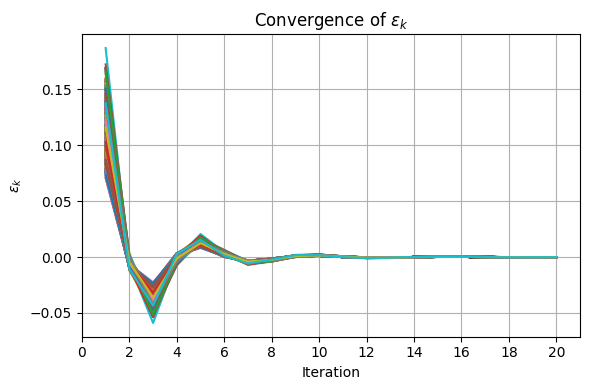

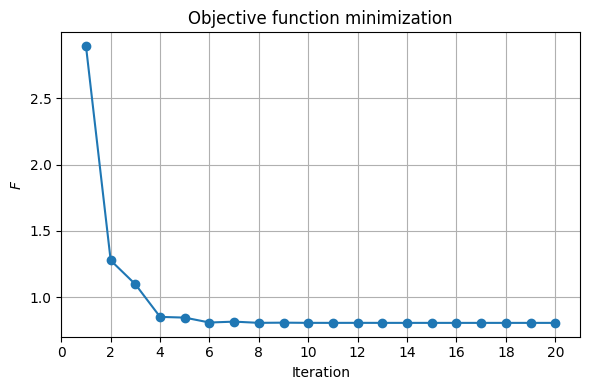

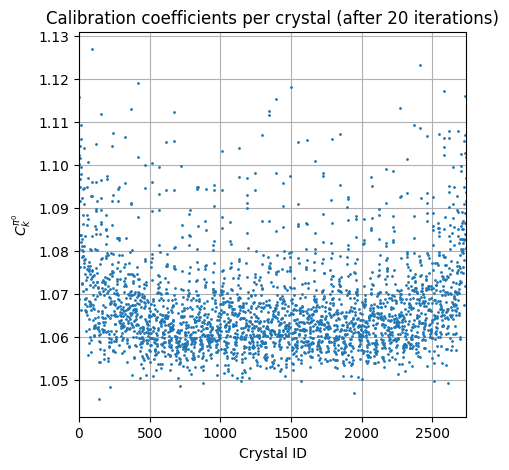

Minimum calibration coefficient: 4.5505238831589745
Maximum calibration coefficient: 12.686999046519155
Mean calibration coefficient: 6.704383203416242


In [ ]:
# Evolution of epsilon
eps_val = np.array(eps_vals)
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(eps_val) + 1), eps_val)
plt.xlabel("Iteration")
plt.ylabel(r"$\epsilon_k$")
plt.xticks(np.arange(0, 21, 2))
plt.xlim(0,21)
#plt.ylim(-0.002,0.002)
plt.title(r"Convergence of $\epsilon_k$")
plt.grid(True)
plt.tight_layout()
plt.show()

# Objective function F
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(F_vals) + 1), F_vals, marker='o')
plt.xticks(np.arange(0, 21, 2))
plt.xlim(0,21)
plt.xlabel("Iteration"); plt.ylabel(r"$F$"); plt.title("Objective function minimization"); plt.grid(True)
plt.tight_layout(); plt.show()

# Calibration Coefficients
plt.figure(figsize=(5, 5))
plt.plot(calib_df["crystal_id"], calib_df["C_pi0"],
         marker='o', linestyle='none', markersize=1)
plt.xlabel("Crystal ID")
#plt.ylim(1,1.15)
plt.xlim(0,2741)
plt.ylabel(r"$C_k^{\pi^0}$")
plt.title("Calibration coefficients per crystal (after 20 iterations)")
plt.grid(True)
#plt.tight_layout()
plt.show()

# Minimum calibration coefficients
print(f"Minimum calibration coefficient: {(calib_df['C_pi0'].min()-1)*100}")
# Maximum
print(f"Maximum calibration coefficient: {(calib_df['C_pi0'].max()-1)*100}")
# Mean
print(f"Mean calibration coefficient: {(calib_df['C_pi0'].mean()-1)*100}")

In [ ]:
calib_df = pd.DataFrame({"crystal_id": crystal_ids,
                         "C_pi0": C_pi0})
calib_df.to_csv("calibration_constants_pi0_5x41_8it_run1to50_mod_ok.csv", index=False)

Min number of hits: 128.0
Max number of hits: 3734.0


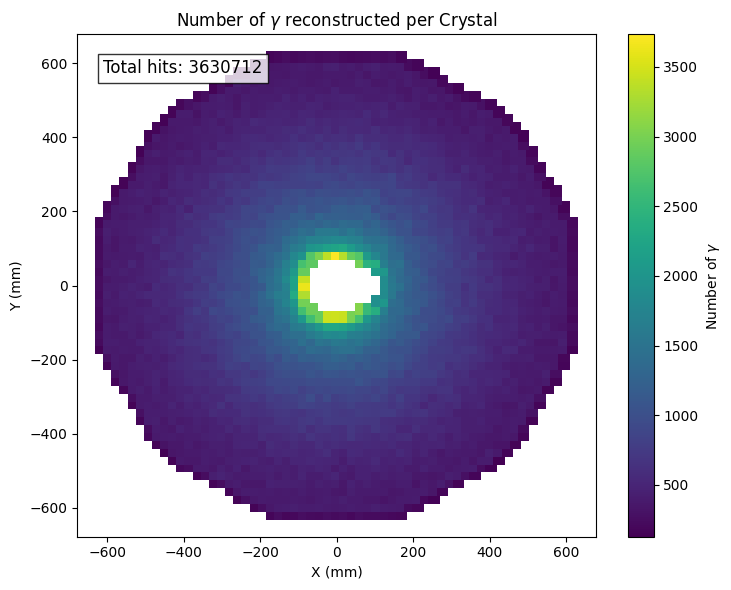

In [ ]:
# Plot number of hits per crystal position

crystal_usage = (E > 0).sum(axis=0)  # number of hits per crystal
crystal_positions = pd.read_csv("crystal_id_xy.csv")
# Merge with crystal usage
crystal_positions = crystal_positions.merge(
    pd.DataFrame({"crystal_id": crystal_ids, "usage": crystal_usage*2}),
    on="crystal_id", how="left"
)

min_entries = crystal_positions["usage"].min()
# Second min number
#min_entries = crystal_positions["usage"].sort_values().unique()[1]
max_entries = crystal_positions["usage"].max()
print(f"Min number of hits: {min_entries}")
print(f"Max number of hits: {max_entries}")

# Total number of hits in the dataset
total_hits = crystal_usage.sum()*4

plt.figure(figsize=(7.5, 6)) #10, 8 is the original
plt.scatter(crystal_positions["x"], crystal_positions["y"],
            c=crystal_positions["usage"], cmap='viridis', s=70, edgecolor='none', marker='s')
plt.colorbar(label=r"Number of $\gamma$")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title(r"Number of $\gamma$ reconstructed per Crystal")
plt.text(0.05, 0.95, f"Total hits: {total_hits}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
#plt.grid(True)
plt.tight_layout()
plt.show()

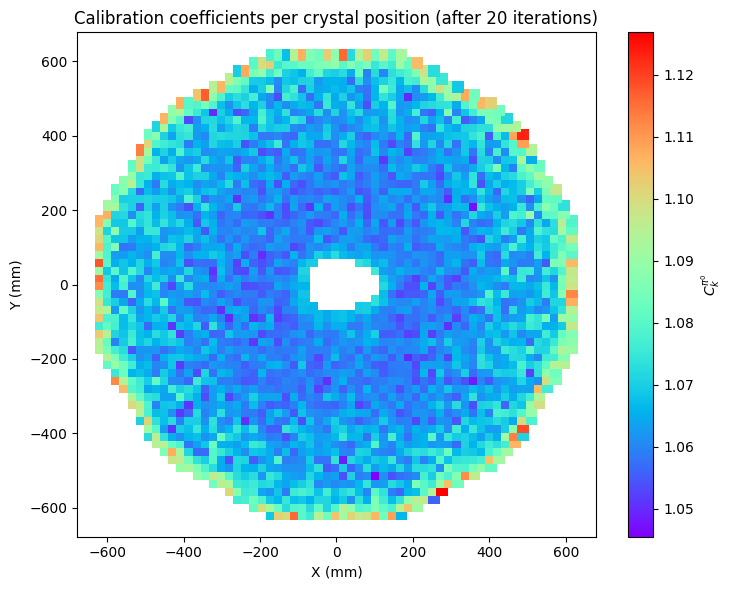

In [ ]:
# Plot a color map of the final calibration constants per crystal position

# Load crystal positions
crystal_positions = pd.read_csv("crystal_id_xy.csv")
# Merge with calibration constants
calib_df = calib_df.drop(columns=["x", "y"], errors='ignore')
calib_df = calib_df.merge(crystal_positions, on="crystal_id", how="left")
plt.figure(figsize=(7.5, 6))

# square markers for crystal positions
plt.scatter(calib_df["x"], calib_df["y"], c=calib_df["C_pi0"],
            cmap='rainbow', s=70, edgecolor='none', marker='s')
plt.colorbar(label=r"$C_k^{\pi^0}$")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title("Calibration coefficients per crystal position (after 20 iterations)")
#plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
numberOfEvents = 8192575 + 10271780 + 9243537 + 9143986 + 8964359 #5x41
print(numberOfEvents)

45816237


In [ ]:
numberOfEvents_before = 47221865 + 46824870 #18x275
print(numberOfEvents_before)

94046735


In [ ]:
# From Run 1 to 27. 18x275
numberOfEvents = 3929928 + 3936788 + 3970245 + 2979015 + 2978145 + 2978101 + 2972129 + 2961464
print(numberOfEvents)

12776525


In [ ]:
# From Run 28 to 50. 18x275
numberOfEvents = 3926866 + 3892120 + 3917607 + 3911421 + 3913882 + 2947248 # 28-31, 35-38, 36-39, 40-43, 44-47, 48-50

In [ ]:
# From Run 26 to 50.
numberOfEvents = 4918151 + 4871244 + 4909213 + 4883284 + 4897661

In [ ]:
# From Run 1 to 50. 18x275 # Hard Estimation
numberOfEvents = (4918151 + 4871244 + 4909213 + 4883284 + 4897661)*2

In [ ]:
# From Run 1 to 50. 18x275 # Hard Estimation # Also for the other
numberOfEvents = (4918151 + 4871244 + 4909213 + 4883284 + 4897661)*4
print(numberOfEvents)

97918212


In [ ]:
# From Run 1 to 50. 5x41 # Hard Estimation # Also for the other
numberOfEvents = (9138005 + 9326350 + 9243537 + 9143986 + 8964359)*2
print(numberOfEvents)

91632474


Total Data Taking Time: 34.28 hours
Minimum time to calibrate a crystal: 0.94 hours
Maximum time to calibrate a crystal: 26.78 hours
Mean time to calibrate a crystal: 6.76 hours


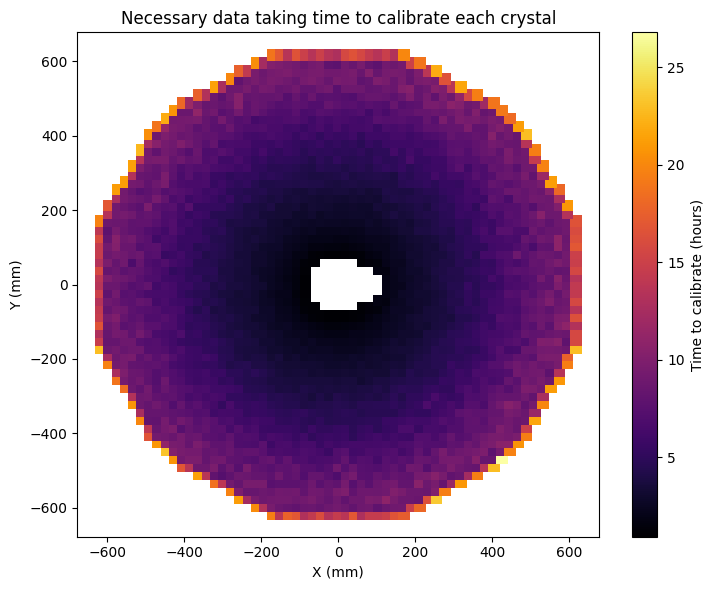

In [ ]:
# Plot the require time to calibrate each crystal position

instLum = 1.0e33 # cm^-2 s^-1 # Expected instantaneous luminosity for the experiment
#SIDIS_crooss_section = 5.36877564e10 # pb # SIDIS cross section at 18x275 GeV
SIDIS_crooss_section = 7.42519148e+05 # pb # SIDIS cross section at 18x275 GeV
#SIDIS_crooss_section = 4.002e+05 # pb # SIDIS cross section at 5x41 GEV
#SIDIS_crooss_section = 2.79e10 # pb # SIDIS cross section at 5x41 GEV
SIDIS_crooss_section = SIDIS_crooss_section * 1.0e-36 # convert to cm^2
#numberEvents = 8.85618e6 # number of events in the dataset for 18x275
numberEvents = numberOfEvents # number of evetns in the dataset for 5x41
intLum = numberEvents / SIDIS_crooss_section # integrated luminosity in cm^-2
dataTakingTime = intLum / instLum / 3600 # in hours

print(f"Total Data Taking Time: {dataTakingTime:.2f} hours")

# Merge with crystal positions
time = np.where(crystal_usage*2 >= 10, 100*dataTakingTime/(crystal_usage*2), 0)
#time = np.where(crystal_usage >= 10, time_before, np.max(time_before))
#time = 100*dataTakingTime/crystal_usage

crystal_positions = crystal_positions.drop(columns=["time"], errors="ignore")
crystal_positions = crystal_positions.merge(
    pd.DataFrame({"crystal_id": crystal_ids, "time": time}),
    on="crystal_id", how="left"
)

# Minimum and maximum time to calibrate a crystal
#min_time = crystal_positions["time"].min()
min_time = min_entries = crystal_positions["time"].sort_values().unique()[1] #Second minimum time
print(f"Minimum time to calibrate a crystal: {min_time:.2f} hours")
max_time = crystal_positions["time"].max()
print(f"Maximum time to calibrate a crystal: {max_time:.2f} hours")
mean_time = crystal_positions["time"].mean()
print(f"Mean time to calibrate a crystal: {mean_time:.2f} hours")

plt.figure(figsize=(7.5, 6))
sc = plt.scatter(crystal_positions["x"], crystal_positions["y"],
                 c=crystal_positions["time"], cmap='inferno',
                 s=70, edgecolor='none', marker='s')

cbar = plt.colorbar(sc, label=r"Time to calibrate (hours)")

plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title(r"Necessary data taking time to calibrate each crystal")
plt.tight_layout()

# Draw a red point at

plt.show()

In [ ]:
instLum = 1.0e33 # cm^-2 s^-1 # Expected instantaneous luminosity for the experiment
#SIDIS_crooss_section = 5.36877564e10 # pb # SIDIS cross section at 18x275 GeV
SIDIS_crooss_section = 7.42519148e+05 # pb # SIDIS cross section at 18x275 GeV
#SIDIS_crooss_section = 4.002e+05 # pb # SIDIS cross section at 5x41 GEV
#SIDIS_crooss_section = 2.79e10 # pb # SIDIS cross section at 5x41 GEV
SIDIS_crooss_section = SIDIS_crooss_section * 1.0e-36 # convert to cm^2
#numberEvents = 8.85618e6 # number of events in the dataset for 18x275
numberEvents = numberOfEvents # number of evetns in the dataset for 5x41
intLum = numberEvents / SIDIS_crooss_section # integrated luminosity in cm^-2
dataTakingTime = intLum / instLum / 3600 # in hours

print(dataTakingTime)
print(intLum)

9.157845762831876
3.296824474619475e+37


Index(['event', 'photon', 'crystal_id', 'x', 'y', 'photon_energy'], dtype='object')
(5252810, 6)


/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:7065: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:7066: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

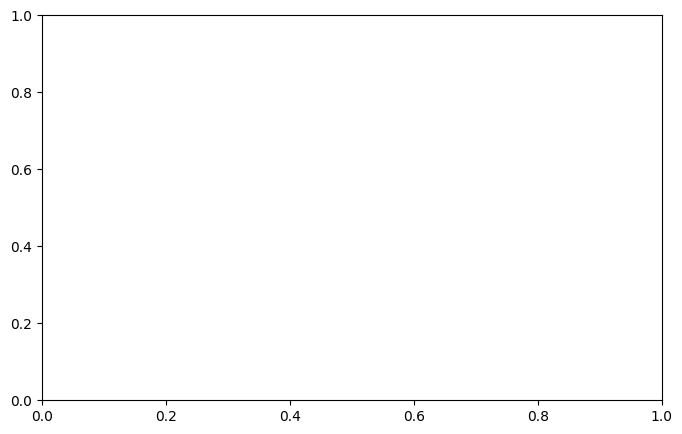

In [ ]:
# Load photon data
df = pd.read_csv("photon_output_18x275_25.03.01_run1to50_mod_ok_FIXED_FINAL.csv")
df["crystal_id"] = df["crystal_id"].astype(int)
print(df.columns)
print(df.shape)

# Set z-coordinate constant
z = -1850.130
df["r3"] = np.sqrt(df["x"]**2 + df["y"]**2 + z**2)
df["ux"] = df["x"] / df["r3"]
df["uy"] = df["y"] / df["r3"]
df["uz"] = z / df["r3"]

# Pivot data: one row per event with both photons
wide = df.pivot(index="event", columns="photon")

# Original
E1 = wide["photon_energy"][1]
E2 = wide["photon_energy"][2]
ux1, uy1, uz1 = wide["ux"][1], wide["uy"][1], wide["uz"][1]
ux2, uy2, uz2 = wide["ux"][2], wide["uy"][2], wide["uz"][2]
cos_theta = ux1 * ux2 + uy1 * uy2 + uz1 * uz2
m2_raw = 2 * E1 * E2 * (1 - cos_theta)
m_raw = np.sqrt(m2_raw)

# Reference π⁰ mass squared (GeV²)
m0_sq = 0.1349766 ** 2

# Plot
plt.figure(figsize=(8, 5))
plt.hist(m_raw * 1000, bins=100, alpha=0.6, label="Raw", linewidth=2)
plt.axvline(np.sqrt(m0_sq)*1000, color='red', linestyle='--', label="Nominal mass")
plt.xlabel(r"$m_{\pi^0}$ [MeV]")
plt.ylabel("Counts")
plt.xlim(80, 180)
plt.title("Reconstructed $\pi^0$ Mass Before and After Calibration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Index(['event', 'photon', 'crystal_id', 'x', 'y', 'photon_energy'], dtype='object')
(5252810, 6)


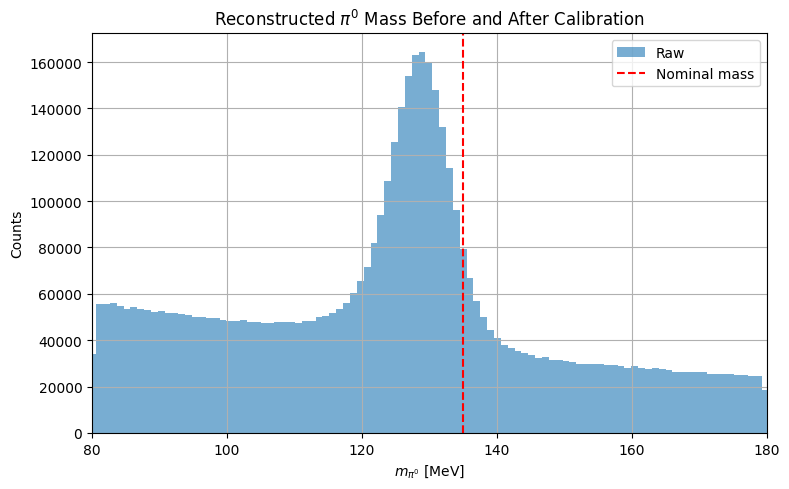

In [ ]:
# Load photon data
df = pd.read_csv("photon_output_18x275_25.03.01_run1to50_mod_ok_FIXED_FINAL.csv")
df["crystal_id"] = df["crystal_id"].astype(int)

# Assign proper event numbers (one per photon pair)
df["event"] = (df.index // 2) + 1

print(df.columns)
print(df.shape)

# Set z-coordinate constant
z = -1850.130
df["r3"] = np.sqrt(df["x"]**2 + df["y"]**2 + z**2)
df["ux"] = df["x"] / df["r3"]
df["uy"] = df["y"] / df["r3"]
df["uz"] = z / df["r3"]

# Pivot data: one row per event with both photons
wide = df.pivot(index="event", columns="photon")

# Original
E1 = wide["photon_energy"][1]
E2 = wide["photon_energy"][2]
ux1, uy1, uz1 = wide["ux"][1], wide["uy"][1], wide["uz"][1]
ux2, uy2, uz2 = wide["ux"][2], wide["uy"][2], wide["uz"][2]
cos_theta = ux1 * ux2 + uy1 * uy2 + uz1 * uz2
m2_raw = 2 * E1 * E2 * (1 - cos_theta)
m_raw = np.sqrt(m2_raw)

# Reference π⁰ mass squared (GeV²)
m0_sq = 0.1349766 ** 2

# Plot
plt.figure(figsize=(8, 5))
plt.hist(np.concatenate([m_raw, m_raw]) * 1000, bins=100, alpha=0.6, label="Raw", linewidth=2)
plt.axvline(np.sqrt(m0_sq)*1000, color='red', linestyle='--', label="Nominal mass")
plt.xlabel(r"$m_{\pi^0}$ [MeV]")
plt.ylabel("Counts")
plt.xlim(80, 180)
plt.title("Reconstructed $\pi^0$ Mass Before and After Calibration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Load calibration constants
calib = pd.read_csv("calibration_constants_pi0_18x275_15it_run1to25_mod_ok.csv")
# Drop coloumns x and y
#calib = calib.drop(columns=["x", "y"])
calib["crystal_id"] = calib["crystal_id"].astype(int)
print(calib.columns)

Index(['crystal_id', 'C_pi0'], dtype='object')


In [ ]:
df = df.merge(calib, on="crystal_id", how="left")
df["C_pi0"] = df["C_pi0"].fillna(1.0)
print(df.columns)

Index(['event', 'photon', 'crystal_id', 'x', 'y', 'photon_energy', 'r3', 'ux',
       'uy', 'uz', 'C_pi0'],
      dtype='object')


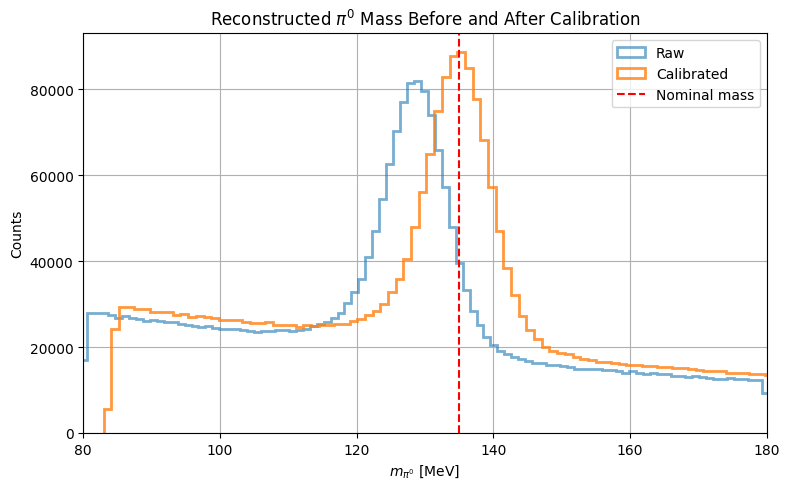

In [ ]:
df["photon_energy_calibrated"] = df["photon_energy"] * df["C_pi0"]

# Set z-coordinate constant
z = -1850.130
df["r3"] = np.sqrt(df["x"]**2 + df["y"]**2 + z**2)
df["ux"] = df["x"] / df["r3"]
df["uy"] = df["y"] / df["r3"]
df["uz"] = z / df["r3"]

# Pivot data: one row per event with both photons
wide = df.pivot(index="event", columns="photon")

# Original
E1 = wide["photon_energy"][1]
E2 = wide["photon_energy"][2]
ux1, uy1, uz1 = wide["ux"][1], wide["uy"][1], wide["uz"][1]
ux2, uy2, uz2 = wide["ux"][2], wide["uy"][2], wide["uz"][2]
cos_theta = ux1 * ux2 + uy1 * uy2 + uz1 * uz2
m2_raw = 2 * E1 * E2 * (1 - cos_theta)
m_raw = np.sqrt(m2_raw)

# Calibrated
E1_corr = wide["photon_energy_calibrated"][1]
E2_corr = wide["photon_energy_calibrated"][2]
m2_corr = 2 * E1_corr * E2_corr * (1 - cos_theta)
m_corr = np.sqrt(m2_corr)
# Reference π⁰ mass squared (GeV²)
m0_sq = 0.134977 ** 2

# Plot
plt.figure(figsize=(8, 5))
plt.hist(m_raw * 1000, bins=100, alpha=0.6, label="Raw", histtype="step", linewidth=2)
plt.hist(m_corr * 1000, bins=100, alpha=0.8, label="Calibrated", histtype="step", linewidth=2)
plt.axvline(np.sqrt(m0_sq)*1000, color='red', linestyle='--', label="Nominal mass")
plt.xlabel(r"$m_{\pi^0}$ [MeV]")
plt.ylabel("Counts")
plt.xlim(80, 180)
plt.title("Reconstructed $\pi^0$ Mass Before and After Calibration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Index(['event', 'photon', 'crystal_id', 'x', 'y', 'photon_energy'], dtype='object')
(2789414, 6)


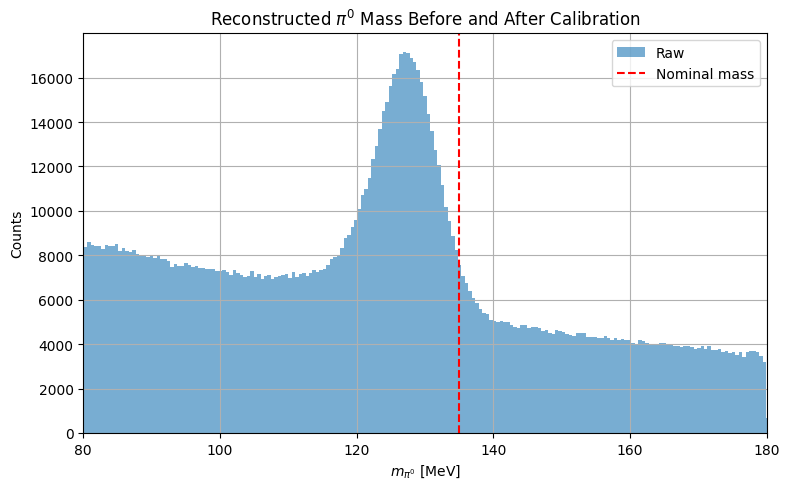

Bin of the peak value: 46
Mass of the peak: 126.71685626037822


In [ ]:
# Load photon data
#df = pd.read_csv("photon_output_5x41.csv")
#df = pd.read_csv("Combined_Photon_Output_Run1to50.csv")
#df = pd.read_csv("Photon_Output_Run1to50_5x41_80to180.csv")
df = pd.read_csv("photon_output_5x41_25.03.01_run1to50_mod_ok.csv")
df["crystal_id"] = df["crystal_id"].astype(int)

# Assign proper event numbers (one per photon pair)
#df["event"] = (df.index // 2) + 1

print(df.columns)
print(df.shape)

# Set z-coordinate constant
z = -1850.130
df["r3"] = np.sqrt(df["x"]**2 + df["y"]**2 + z**2)
df["ux"] = df["x"] / df["r3"]
df["uy"] = df["y"] / df["r3"]
df["uz"] = z / df["r3"]

# Pivot data: one row per event with both photons
wide = df.pivot(index="event", columns="photon")

# Original
E1 = wide["photon_energy"][1]
E2 = wide["photon_energy"][2]
ux1, uy1, uz1 = wide["ux"][1], wide["uy"][1], wide["uz"][1]
ux2, uy2, uz2 = wide["ux"][2], wide["uy"][2], wide["uz"][2]
cos_theta = ux1 * ux2 + uy1 * uy2 + uz1 * uz2
m2_raw = 2 * E1 * E2 * (1 - cos_theta)
m_raw = np.sqrt(m2_raw)

# Reference π⁰ mass squared (GeV²)
m0_sq = 0.134977 ** 2

# Plot
plt.figure(figsize=(8, 5))
plt.hist(m_raw * 1000, bins=200, alpha=0.6, label="Raw", linewidth=2)
plt.axvline(np.sqrt(m0_sq)*1000, color='red', linestyle='--', label="Nominal mass")
plt.xlabel(r"$m_{\pi^0}$ [MeV]")
plt.ylabel("Counts")
plt.xlim(80, 180)
#plt.ylim(0, 4000)
plt.title("Reconstructed $\pi^0$ Mass Before and After Calibration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Print the bin of the peak value
print(f"Bin of the peak value: {np.argmax(np.histogram(m_raw * 1000, bins=100)[0])}")
# This bin correspond to a mass of
print(f"Mass of the peak: {np.histogram(m_raw * 1000, bins=200)[1][np.argmax(np.histogram(m_raw * 1000, bins=200)[0])]}")

In [ ]:
# Load calibration constants
calib = pd.read_csv("calibration_constants_pi0_5x41_12it_run1to50_mod_ok.csv")
# Drop coloumns x and y
#calib = calib.drop(columns=["x", "y"])
calib["crystal_id"] = calib["crystal_id"].astype(int)
print(calib.columns)

Index(['crystal_id', 'C_pi0'], dtype='object')


In [ ]:
df = df.merge(calib, on="crystal_id", how="left")
df["C_pi0"] = df["C_pi0"].fillna(1.0)
print(df.columns)

Index(['event', 'photon', 'crystal_id', 'x', 'y', 'photon_energy', 'r3', 'ux',
       'uy', 'uz', 'C_pi0'],
      dtype='object')


In [ ]:
# Fit m_corr
from scipy.optimize import curve_fit

def gaus_plus_pol1(x, A, mu, sigma, d0, d1):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + d0 + d1 * x

-0.2876020115005957


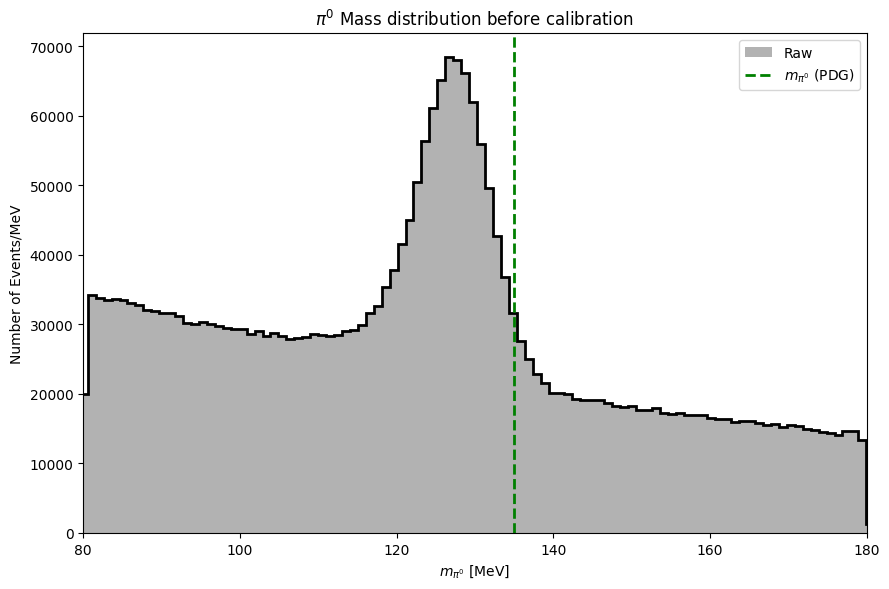

In [ ]:
df["photon_energy_calibrated"] = df["photon_energy"] * df["C_pi0"]

# Set z-coordinate constant
z = -1850.130
df["r3"] = np.sqrt(df["x"]**2 + df["y"]**2 + z**2)
df["ux"] = df["x"] / df["r3"]
df["uy"] = df["y"] / df["r3"]
df["uz"] = z / df["r3"]

# Pivot data: one row per event with both photons
wide = df.pivot(index="event", columns="photon")

# Original
E1 = wide["photon_energy"][1]
E2 = wide["photon_energy"][2]
ux1, uy1, uz1 = wide["ux"][1], wide["uy"][1], wide["uz"][1]
ux2, uy2, uz2 = wide["ux"][2], wide["uy"][2], wide["uz"][2]
cos_theta = ux1 * ux2 + uy1 * uy2 + uz1 * uz2
m2_raw = 2 * E1 * E2 * (1 - cos_theta)
m_raw = np.sqrt(m2_raw)

# Calibrated
E1_corr = wide["photon_energy_calibrated"][1]
E2_corr = wide["photon_energy_calibrated"][2]
m2_corr = 2 * E1_corr * E2_corr * (1 - cos_theta)
m_corr = np.sqrt(m2_corr)
# Reference π⁰ mass squared (GeV²)
m0_sq = 0.1349766 ** 2

# Fit a model
counts, bin_edges = np.histogram(np.concatenate([m_corr, m_corr]) * 1000, bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Initial parameters: A, mu, sigma, d0, d1
massPDG = np.sqrt(m0_sq) * 1000
initial_guess = [4000, massPDG, 5, 1000, -5]


# Fit
popt, pcov = curve_fit(gaus_plus_pol1, bin_centers, counts, p0=initial_guess)

# Extract fit parameters
A, mu, sigma, d0, d1 = popt
perr = np.sqrt(np.diag(pcov))  # standard deviations (sqrt of diagonal)
mu_err = perr[1]
sigma_err = perr[2]

# Error of the fit and the expected data
mass_uncertaintity = 100 - mu*100/massPDG
print(mass_uncertaintity)

# Text string
textstr = '\n'.join((
    r'$m_{\pi^0 Fit} = %.4f \pm %.4f$' % (mu, mu_err),
    r'$\sigma_m = %.4f \pm %.4f$' % (sigma, sigma_err)
))

# Define 2σ range
x_fit = np.linspace(mu - 2*sigma, mu + 2*sigma, 1000)

# Plot
plt.figure(figsize=(9, 6))
plt.hist(np.concatenate([m_raw, m_raw]) * 1000, bins=100, label="Raw", facecolor='black', edgecolor='none', alpha=0.3, histtype='stepfilled')
plt.hist(np.concatenate([m_raw, m_raw]) * 1000, bins=100, facecolor='none', edgecolor='black', linewidth=2, histtype='step')
#plt.hist(np.concatenate([m_corr, m_corr]) * 1000, bins=100, label="Calibrated", facecolor='blue', edgecolor='none', alpha=0.3, histtype='stepfilled')
#plt.hist(np.concatenate([m_corr, m_corr]) * 1000, bins=100, facecolor='none', edgecolor='blue', linewidth=2, histtype='step')
#plt.plot(x_fit, gaus_plus_pol1(x_fit, *popt), 'r-', label="Fit")
plt.axvline(np.sqrt(m0_sq)*1000, color='green', linestyle='--', label=r"$m_{\pi^0}$ (PDG)", linewidth=2)
plt.xlabel(r"$m_{\pi^0}$ [MeV]")
plt.ylabel("Number of Events/MeV")
# Increase label size
plt.tick_params(axis='both', labelsize=10)

# Add text box
#plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlim(80, 180)
#plt.ylim(2500, 20000)
#plt.title(f"Reconstructed $\pi^0$ Mass Before and After Calibration (After 20 iterations)")
plt.title(f"$\pi^0$ Mass distribution before calibration")
plt.legend()
plt.grid(0)
plt.tight_layout()
plt.show()

In [ ]:
iterations = np.array([6, 8, 10, 12, 14, 16, 18, 20, 22])
fitted_mass = np.array([134.4749, 135.5651, 134.3010, 135.0106, 134.8324, 134.8242, 134.8719, 134.8382, 134.8519])
#fitted_mass = np.array([134.4749, 135.5651, 134.3010, 135.0106, 134.8324, 135.0374, 134.8719, 134.8382, 134.8519])
uncertainty = np.array([0.1820, 0.2082, 0.1970, 0.1987, 0.2005, 0.2002, 0.1998, 0.1998, 0.1998])
mass_diff_uncertainty = np.array([2.7566, 2.8266, 3.4294, 0.1711, 0.7192, 0.7624, 0.5240, 0.6927, 0.6241])

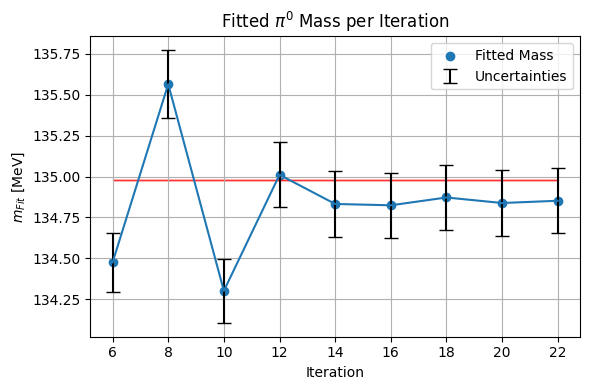

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(iterations, fitted_mass, label="Fitted Mass")
plt.errorbar(iterations, fitted_mass, yerr=uncertainty, c="Blue", ecolor="Black", linestyle="", capsize=5, label="Uncertainties")
plt.plot(iterations, fitted_mass)
#plt.axhline(y=134.9766, color='r', linestyle='--', label=r"$m_{\pi^0}$ (PDG)")
# Plot the are within 134.9766 +/- 0.0006
plt.fill_between(iterations, 134.9766-0.0006, 134.9766+0.0006, color='red', alpha=0.8)
plt.xlabel("Iteration")
plt.ylabel(r"$m_{Fit}$ [MeV]")
plt.title("Fitted $\pi^0$ Mass per Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

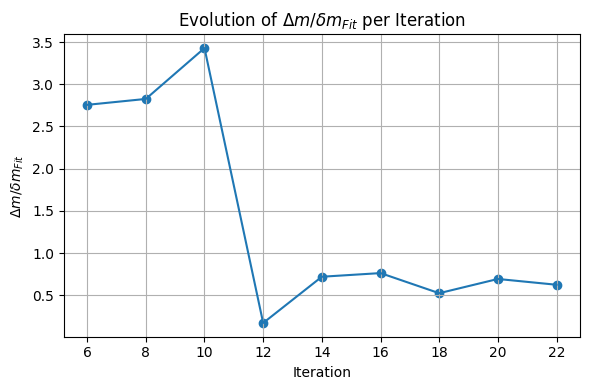

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(iterations, mass_diff_uncertainty)
plt.plot(iterations, mass_diff_uncertainty)
plt.xlabel("Iteration")
plt.ylabel(r"$\Delta m$/$\delta m_{Fit}$")
plt.title(r"Evolution of $\Delta m$/$\delta m_{Fit}$ per Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Identify rows causing the ValueError
# This requires re-running the problematic pivot operation with error handling
try:
    wide = df.pivot(index="event", columns="photon")
except ValueError as e:
    print(f"ValueError: {e}")
    # The error message indicates duplicate entries in the index/columns combination.
    # We can find these by looking at the original DataFrame for events
    # where the combination of 'event' and 'photon' is not unique.
    duplicate_rows = df[df.duplicated(['event', 'photon'], keep=False)]
    print("\nRows causing the ValueError:")
    display(duplicate_rows)

In [ ]:
iterations = np.array([6, 8, 10, 12, 14, 16, 18, 20, 22])
fitted_mass = np.array([134.8075, 135.9293, 134.7666, 135.3648, 135.1886, 135.1786, 135.2274, 135.1928, 135.2075])
#fitted_mass = np.array([134.4749, 135.5651, 134.3010, 135.0106, 134.8324, 135.0374, 134.8719, 134.8382, 134.8519])
uncertainty = np.array([0.1908, 0.2145, 0.2056, 0.2040, 0.2054, 0.2041, 0.2046, 0.2046, 0.2045])
#mass_diff_uncertainty = np.array([2.7566, 2.8266, 3.4294, 0.1711, 0.7192, 0.7624, 0.5240, 0.6927, 0.6241])
mass_diff_uncertainty = np.abs(massPDG - fitted_mass) / uncertainty

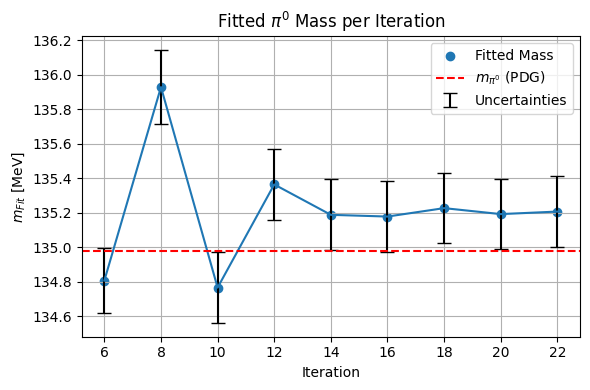

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(iterations, fitted_mass, label="Fitted Mass")
plt.errorbar(iterations, fitted_mass, yerr=uncertainty, c="Blue", ecolor="Black", linestyle="", capsize=5, label="Uncertainties")
plt.plot(iterations, fitted_mass)
plt.axhline(y=134.9766, color='r', linestyle='--', label=r"$m_{\pi^0}$ (PDG)")
# Plot the are within 134.9766 +/- 0.0006
#plt.fill_between(iterations, 134.9766-0.0006, 134.9766+0.0006, color='red', alpha=0.8)
plt.xlabel("Iteration")
plt.ylabel(r"$m_{Fit}$ [MeV]")
plt.title("Fitted $\pi^0$ Mass per Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

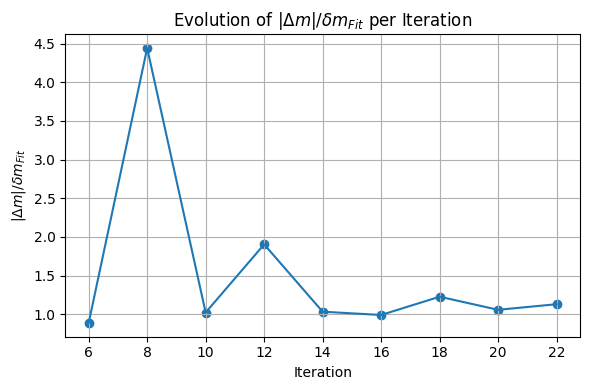

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(iterations, mass_diff_uncertainty)
plt.plot(iterations, mass_diff_uncertainty)
plt.xlabel("Iteration")
plt.ylabel(r"$|\Delta m|$/$\delta m_{Fit}$")
plt.title(r"Evolution of $|\Delta m|$/$\delta m_{Fit}$ per Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()